## Strikeout Percentage Prediction
Objective: 

- Given a set of data ranging from 2021 to 2025 that includes the below features, I wanted to predict each player's strikeout percentage in the 2025 season. Predicting strikeout percentage can allow for decisions to be made regarding potential trades, continued performance of valuable players, and can be extended to draft assistance if Minor league or college data were implemented.
- One of my primary goals is to make a model that is interpretable so that decisions can be made using the model as opposed to a more black box style solution where making conclusions and recommendations may be more complicated.

Available data:
    
- Season
- Name
- PlayerId
- Team (entry for multi-team seasons is '---')
- K% (strikeout percentage)
- TBF (Total Batters Faced this season)
- Age
- Stuff+ (composite sabermetric, average across all pitches in a season)
    - Incorporates multiple objective measures of a pitch into a score, with 100 being the league average

Considerations: 

What is the range of data available per player? Consider how inputs, techniques, outcomes, and prediction performance will be affected by rookie vs. veteran data availability. Considering the value of Stuff+ is relative to a league average, how does the value of the scores change per season in terms of interpretability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
zlink = "k_2026.csv"
df_raw = pd.read_csv(link, header=0)

In [3]:
df_raw.head()

,Season,Name,PlayerId,Team,K%,TBF,Stuff+,Age
0,2021,Francisco Mejía,642336,TBR,0.0,14,-11.100000,25
1,2021,Josh Reddick,502210,ARI,0.0,5,-11.018824,34
2,2021,Albert Almora Jr.,546991,NYM,0.0,6,9.100000,27
3,2021,Anthony Bemboom,621532,LAA,0.0,7,15.120000,31
4,2021,Austin Wynns,642851,BAL,0.0,4,20.426667,30


I want to start by evaluating the data I have from a high level. I'm looking for missing values, outliers, potential data entry issues, data formats, and anything unexpected. The describe() function tells me that we have data from 2021 to 2025, we have pitchers facing a broad range of total batters (1 to 886), and a wider range of Stuff+ values than I expected, including negative values.

In [4]:
df_raw.describe()

,Season,PlayerId,K%,TBF,Stuff+,Age
count,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000
mean,2022.979867,631248.047586,0.203989,208.956303,95.356530,28.518874
std,1.423264,58227.510557,0.089016,205.159360,18.201834,3.612374
min,2021.000000,405395.000000,0.000000,1.000000,-46.510769,20.000000
25%,2022.000000,605446.500000,0.163934,47.000000,91.141573,26.000000
50%,2023.000000,656322.000000,0.209459,153.000000,97.907847,28.000000
75%,2024.000000,669622.000000,0.253731,278.000000,104.773245,31.000000
max,2025.000000,829272.000000,1.000000,886.000000,149.210800,45.000000


In [5]:
# Checking for NA quickly. This doesn't mean we don't have missing values, but nothing is importing as NA, at least.
df_raw.isna().sum()

Season      0
Name        0
PlayerId    0
Team        0
K%          0
TBF         0
Stuff+      0
Age         0
dtype: int64

In [6]:
# Making sure the data types are conducive to arithmetic as needed (I don't want K% coming in as a string, for example).
print(df_raw.dtypes)

Season        int64
Name            str
PlayerId      int64
Team            str
K%          float64
TBF           int64
Stuff+      float64
Age           int64
dtype: object


In [7]:
# Remove the 2025 related data because I would not have this information when determining how to approach the prediction for 2025.

mask = df_raw["Season"].astype(str).str.contains("2025")
df = df_raw[
    ~mask
].copy()  # Maintain 2021-2024 rows for initial decision making and model training.

Let's do a quick gut check to see what's going on with correlations just in case we need to address multicollinearity down the line with the model.  Looks like K% and Stuff+ are showing a moderate correlation around 0.6. Age has some negative correlations, which is not surprising. My initial thoughts about Age as a variable are that it makes sense to have minimal correlation because there is likely an inflection point where increasing age becomes detrimental to strikeout percentage, but may improve strikeout percentage from ages 21 to 22, for example.


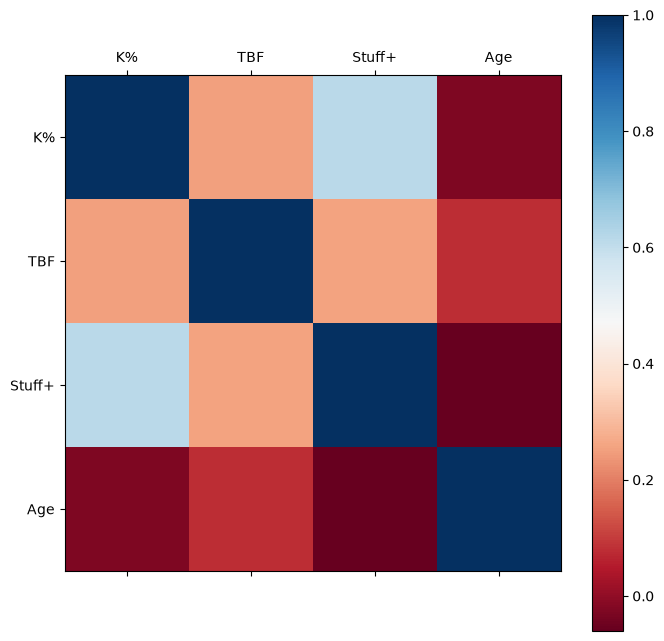

In [8]:
cols = ["K%", "TBF", "Stuff+", "Age"]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr, cmap="RdBu")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)

fig.colorbar(cax)
plt.show()

Time to visualize some of the data (specifically, the target variable) so we can get a better feel for what we're dealing with. It looks like there's some general consistency across seasons, on average, with some 1.0 values present in 2021. So, what's going on with those values? It could be someone who faced 1 batter and struck them out, so this makes me think about the limitations of K% as a predictor and a target variable instead of simply the target variable.

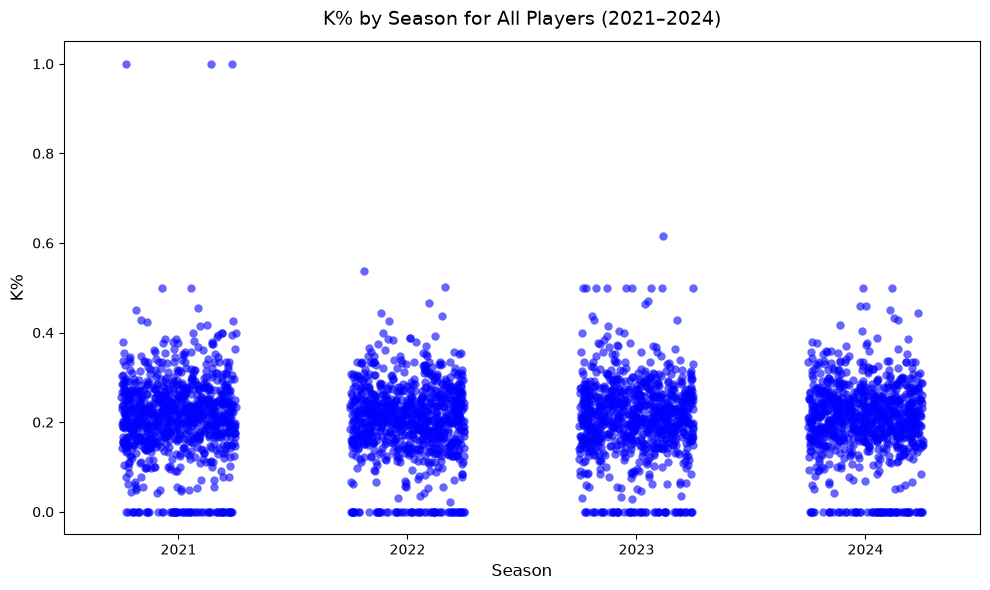

In [9]:
plt.figure(figsize=(10, 6))

ax = sns.stripplot(
    data=df,
    x="Season",
    y="K%",
    jitter=0.25,
    alpha=0.6,
    size=6,
    color="blue",
)

plt.title("K% by Season for All Players (2021–2024)", fontsize=14, pad=12)
plt.xlabel("Season", fontsize=12)
plt.ylabel("K%", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# What's going on with the max values of K% in 2021? Players who faced one batter and struck them out have a 100% score.
# This confirms that it's possible to have a maximum K% simply by facing limited batters instead of being indicative of performance.
# I want to be careful with that and discourage the model from using that to predict another 100% season.
df[df["K%"] == df["K%"].max()]

,Season,Name,PlayerId,Team,K%,TBF,Stuff+,Age
21,2021,Mike Freeman,502273,CIN,1.0,1,40.40,33
42,2021,Romy Gonzalez,663853,CHW,1.0,1,58.05,24
52,2021,Nick Maton,665155,PHI,1.0,1,69.66,24


Some players have played on multiple teams per season and are entered into the dataset as '- - -.' As seen below, this is the case for 520 of the players included, which means this is not an edge case. This is a significant enough chunk of the players that I do not want to exclude them. Why would I exclude them? Because if I use Team as a predictor, then these players will muddy the results by being lumped in as a "team" themselves. Since I don't have direct info (from this exact dataset) on which teams these players played for (if multiple), I will exclude the Team column from inputs into this model. However, Team could certainly have an influence. If it appeared Team had a significant relationship with K%, then in the future I would like some more granular detail on Team per player per season. Some of the potential reasons the Team may have an effect or influence on strikeouts could be pitching staff composition and/or philosophy, load management, game strategy, or strength and conditioning protocols are more effective for a given team that season. I would lose out on this information by dropping Team, however, I would argue that I have a model that is able to predict player performance regardless of their team and "moreso" as an individual. This may be important for making trade decisions and determining if newer training protocols are driving any performance benefits. 

In [11]:
# We would lose a good chunk of players if I was highly concerned with Team, so I'm going to opt to remove Team and include the multi-team players.
print(
    f"Number of players who have played on multiple teams ('---'): {(df_raw["Team"] == "- - -").sum()}"
)

Number of players who have played on multiple teams ('---'): 520


I want to isolate season effects and consider cases when consecutive seasons are not available. Considering the goal is to predict a future season given at least one previous season, I am going to opt to compare data across consecutive seasons instead of the individual seasons themselves. The reason being, I am interested in how the prior season or seasons affect the future season as opposed to treating the seasons as isolated over time. This is in line with the objective of predicting the upcoming season given previous season data. That does come with significant model usage limitations: namely I will not have data for players where I have only 1 season of data or players with data from non-consecutive years. This would remove new league players and potentially injured players who return 1+ years later from the training data. The model then becomes primarily applicable for performing predictions for players where I have consistent years of data (possibly to determine if a trade should be done to acquire a pitcher who we expect to perform well in 2025 and who has been doing well since 2022). The model could absolutely be expanded in the future by handling cases where a player has data for 2021 and 2024 where I introduce, potentially, a penalty term or weight to adjust for that gap where I have no data.

In [12]:
# Creating the season transition rows in a new dataframe and adding a variable that is a count of the actual strikeouts ('K').
# This is effectively performing a self-join to combine data into wider rows for players where I have consecutive season data.

df_t = df_raw.copy()
df_t["K"] = (df_t["K%"] * df_t["TBF"]).round().astype(int)

t = df_t.rename(
    columns={
        "Season": "Season_t",
        "K%": "K%_t",
        "TBF": "TBF_t",
        "K": "K_t",
        "Stuff+": "Stuff+_t",
        "Age": "Age_t",
    }
)[["PlayerId", "Name", "Team", "Season_t", "K%_t", "TBF_t", "K_t", "Stuff+_t", "Age_t"]]

t1 = df_t.rename(
    columns={"Season": "Season_t1", "K%": "K%_t1", "TBF": "TBF_t1", "K": "K_t1"}
)[["PlayerId", "Season_t1", "K%_t1", "TBF_t1", "K_t1"]]

t["Season_t1"] = t["Season_t"] + 1

transitions = t.merge(t1, on=["PlayerId", "Season_t1"], how="inner")

print(
    f"There are {len(transitions)} transition rows from {transitions['PlayerId'].nunique()} players"
)

There are 2442 transition rows from 1069 players


In [13]:
# Quick check to make sure I don't have wildly lopsided numbers across seasons. Doesn't look like it!
print(transitions.groupby("Season_t1")["PlayerId"].nunique())

Season_t1
2022    612
2023    604
2024    611
2025    615
Name: PlayerId, dtype: int64


I am choosing a binomial general linear model for this task because I believe that starting off with a linear regression style of model is worthwile until I have evidence of needing something non linear, non parametric, or otherwise more complicated. I chose a binomial because the outcome variable here is a binary (strikeout or not) and I am able to calculate the exact number of strikeouts and, by extension, any other outcome given the total batters faced. This model squeezes the solution space between 1 and 0 which does add an extra layer of difficulty in interpretability, but assists in modulating the effect of the extremes seen in the data. 

In [ ]:
train_t = transitions[transitions["Season_t1"] <= 2024].copy()
target_t = transitions[transitions["Season_t1"] == 2025].copy()

stuff_mean = train_t["Stuff+_t"].mean()
stuff_std = train_t["Stuff+_t"].std()

kp_mean = train_t["K%_t"].mean()
kp_std = train_t["K%_t"].std()

train_t["stuff_z"] = (train_t["Stuff+_t"] - stuff_mean) / stuff_std
target_t["stuff_z"] = (target_t["Stuff+_t"] - stuff_mean) / stuff_std

train_t["Kp_z"] = (train_t["K%_t"] - kp_mean) / kp_std
target_t["Kp_z"] = (target_t["K%_t"] - kp_mean) / kp_std


glm_model = smf.glm(
    formula="K_t1 + I(TBF_t1 - K_t1) ~ stuff_z + Kp_z",
    data=train_t,
    family=sm.families.Binomial(),
)

glm_results = glm_model.fit(
    cov_type="cluster", cov_kwds={"groups": train_t["PlayerId"]}
)

print(glm_results.summary())

                      Generalized Linear Model Regression Results                       
Dep. Variable:     ['K_t1', 'I(TBF_t1 - K_t1)']   No. Observations:                 1827
Model:                                      GLM   Df Residuals:                     1824
Model Family:                          Binomial   Df Model:                            2
Link Function:                            Logit   Scale:                          1.0000
Method:                                    IRLS   Log-Likelihood:                -7131.4
Date:                          Tue, 08 Sep 2026   Deviance:                       5112.5
Time:                                  18:25:09   Pearson chi2:                 5.10e+03
No. Iterations:                               5   Pseudo R-squ. (CS):             0.7688
Covariance Type:                        cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [15]:
# Checking if these coefficients are telling me the same thing or if they actually are accounting for some difference in variance.
# I would be concerned if it was up at 0.85 or 0.9, so I'll take 0.58 for now.
train_t[["stuff_z", "Kp_z"]].corr()

,stuff_z,Kp_z
stuff_z,1.000000,0.584165
Kp_z,0.584165,1.000000


In [16]:
# Also checking the variance inflaction factor (VIF) to see if I'm under 5 (red flag), and I'm all set here.
X = train_t[["stuff_z", "Kp_z"]].assign(const=1)
vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1] - 1)],
    index=["stuff_z", "Kp_z"],
)
print(vif)

stuff_z    1.518024
Kp_z       1.518024
dtype: float64


In [17]:
# Finally, time to generate predictions.
seen_seasons = train_t["Season_t"].unique()
target_t["season_seen"] = target_t["Season_t"].isin(seen_seasons)
print(target_t["season_seen"].value_counts())

target_t["K%_predicted"] = glm_results.predict(target_t)

print(f"Number of unique players in original dataset: {len(df["PlayerId"].unique())}")
# This confirms I do lose players due to the restrictions of using consecutive seasons.
# That simply means I must carefully choose which players this model can and should be applied to and what conclusions I can make.

season_seen
False    615
Name: count, dtype: int64
Number of unique players in original dataset: 1569


In [18]:
# Check mean and standard deviation of my predictions first and compare them to the input data.
# The means are quite similar, but the similarity diverges at the min and max values.
comparison = pd.concat(
    [target_t["K%_predicted"].describe(), train_t["K%_t1"].describe()],
    axis=1,
    keys=["Predicted 2025 K%", "Actual K%_t1 (train)"],
)

comparison

,Predicted 2025 K%,Actual K%_t1 (train)
count,615.000000,1827.000000
mean,0.219511,0.215335
std,0.041022,0.075212
min,0.060382,0.000000
25%,0.200125,0.175827
50%,0.220292,0.217105
75%,0.241999,0.258270
max,0.359162,0.538462


In [19]:
# Comprehensive evaluation of the actual 2025 outcomes relative to predictions.
# Note: this is only occurring for those players with valid 2025 data.
actual_2025 = df_raw[df_raw["Season"] == 2025][["PlayerId", "K%", "TBF"]].rename(
    columns={"K%": "K%_actual", "TBF": "TBF_actual"}
)

eval_df = target_t.merge(actual_2025, on="PlayerId", how="inner")

In [20]:
def weighted_mae(y_true, y_pred, weights):
    return np.average(np.abs(y_true - y_pred), weights=weights)


def weighted_rmse(y_true, y_pred, weights):
    return np.sqrt(np.average((y_true - y_pred) ** 2, weights=weights))

If I look at the error metrics alone, the model did perform slightly better than the league wide values. The model does perform slightly better than simply carrying over the strikeout percentage from the last seen season, but it likely only performs "better" with the central band of data. The small and large extremes of K% are likely problematic given what is shown in the table above.

In [21]:
w_mae = weighted_mae(
    eval_df["K%_actual"], eval_df["K%_predicted"], eval_df["TBF_actual"]
)
w_rmse = weighted_rmse(
    eval_df["K%_actual"], eval_df["K%_predicted"], eval_df["TBF_actual"]
)

baseline_persistence = weighted_mae(
    eval_df["K%_actual"], eval_df["K%_t"], eval_df["TBF_actual"]
)
league_avg = train_t["K_t1"].sum() / train_t["TBF_t1"].sum()
baseline_league_avg = weighted_mae(
    eval_df["K%_actual"], np.full(len(eval_df), league_avg), eval_df["TBF_actual"]
)

print(f"Model weighted MAE:        {w_mae:.4f}")
print(f"Model weighted RMSE:       {w_rmse:.4f}")
print(f"Persistence baseline MAE:  {baseline_persistence:.4f}")
print(f"League-avg baseline MAE:   {baseline_league_avg:.4f}")

Model weighted MAE:        0.0333
Model weighted RMSE:       0.0424
Persistence baseline MAE:  0.0387
League-avg baseline MAE:   0.0416


Time to take a final look at the distribution of the residuals to see if they're somewhat normally distributed... And they are- mostly. As expected, the tails are a bit off, but the concerning finding is the overprediction of those individuals found on the left tail. Being off by 20% is pretty significant and it's another reason to consider using this model primarily in cases that don't  involve players with incredibly high or incredibly low TBF.

AME of +1 SD Stuff+ (holding prior K% at observed values): 1.97 percentage points
AME of +1 SD prior K% (holding Stuff+ at observed values): 2.91 percentage points
Predicted K% for an average pitcher (Stuff+ and prior K% at league mean): 22.00%


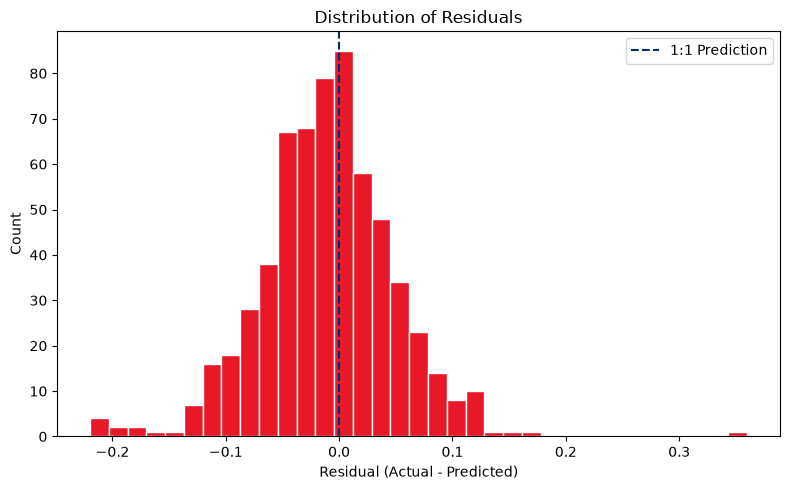

In [23]:
# Average Marginal Error (AME)
baseline = glm_results.predict(train_t)
bumped_stuff = glm_results.predict(train_t.assign(stuff_z=train_t["stuff_z"] + 1))
ame_stuff = (bumped_stuff - baseline).mean()

bumped_kp = glm_results.predict(train_t.assign(Kp_z=train_t["Kp_z"] + 1))
ame_kp = (bumped_kp - baseline).mean()

print(
    f"AME of +1 SD Stuff+ (holding prior K% at observed values): {ame_stuff*100:.2f} percentage points"
)
print(
    f"AME of +1 SD prior K% (holding Stuff+ at observed values): {ame_kp*100:.2f} percentage points"
)

avg_pitcher_pred = glm_results.predict(pd.DataFrame({"stuff_z": [0], "Kp_z": [0]}))
print(
    f"Predicted K% for an average pitcher (Stuff+ and prior K% at league mean): {avg_pitcher_pred.iloc[0]*100:.2f}%"
)

# Disribution of residual visual
eval_df["residual"] = eval_df["K%_actual"] - eval_df["K%_predicted"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(eval_df["residual"], bins=35, color="#e81828", edgecolor="white")
ax.axvline(0, linestyle="--", color="#002D72", label="1:1 Prediction")
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Residuals")
ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# I want to run a quick comparison of an XGBoost model to see what the differences are with this data.
# This will produce some MAE values to compare the XGBoost model to the binomial GLM model with the same features.
# The tree model doesn't require standardization so that makes the first steps a bit easier.
features_matched = [
    "Stuff+_t",
    "K%_t",
]

X_train_matched = train_t[features_matched]
X_target_matched = target_t[features_matched]
y_train = train_t["K%_t1"]
w_train = train_t["TBF_t1"]

xgb_model_matched = xgb.XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42
)

xgb_model_matched.fit(X_train_matched, y_train, sample_weight=w_train)
target_t["K%_predicted_xgb_matched"] = xgb_model_matched.predict(X_target_matched)

# ── 2. Re-evaluate with matched features ───────────────────────────────
eval_df_xgb_matched = target_t.merge(actual_2025, on="PlayerId", how="inner")

w_mae_xgb_matched = weighted_mae(
    eval_df_xgb_matched["K%_actual"],
    eval_df_xgb_matched["K%_predicted_xgb_matched"],
    eval_df_xgb_matched["TBF_actual"],
)
print(f"XGBoost (matched features) weighted MAE: {w_mae_xgb_matched:.4f}")
print(f"GLM weighted MAE:                        {w_mae:.4f}")
print(f"XGBoost (with TBF_t) weighted MAE:        0.0318 (previous result)")

eval_df_xgb_matched["residual_xgb"] = (
    eval_df_xgb_matched["K%_actual"] - eval_df_xgb_matched["K%_predicted_xgb_matched"]
)
eval_df["residual_glm"] = eval_df["K%_actual"] - eval_df["K%_predicted"]

XGBoost (matched features) weighted MAE: 0.0330
GLM weighted MAE:                        0.0333
XGBoost (with TBF_t) weighted MAE:        0.0318 (previous result)


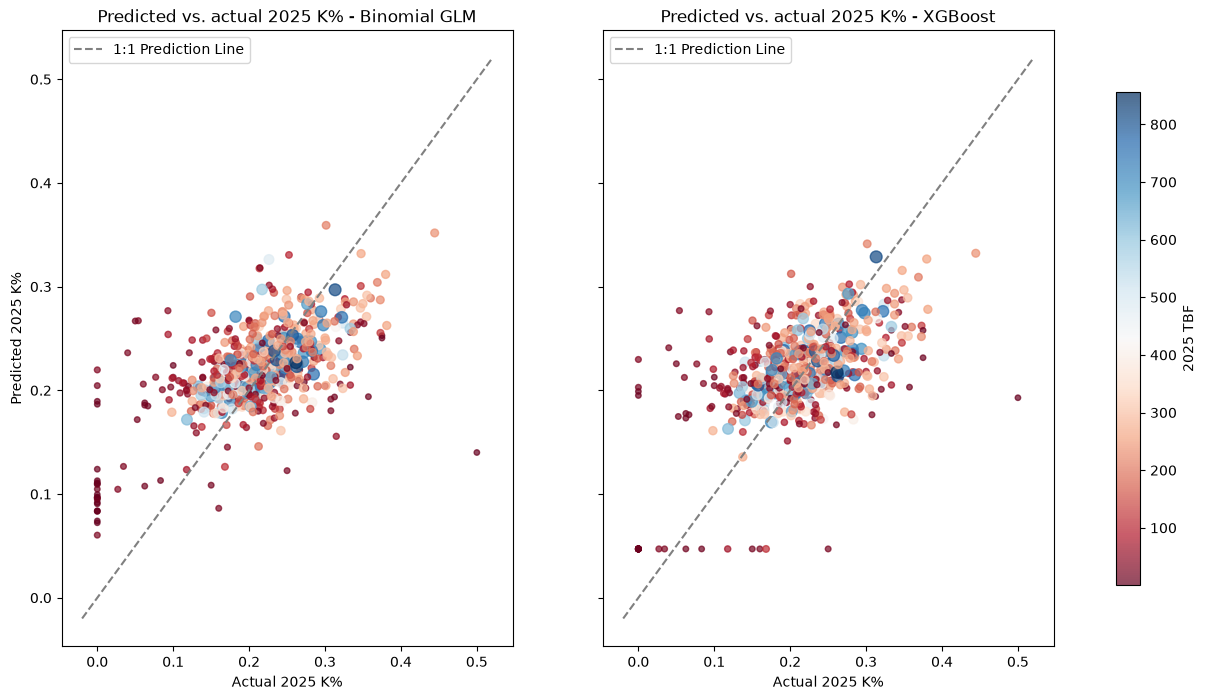

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

sizes_glm = 15 + 60 * (eval_df["TBF_actual"] / eval_df["TBF_actual"].max())

scatter_glm = axes[0].scatter(
    eval_df["K%_actual"],
    eval_df["K%_predicted"],
    s=sizes_glm,
    alpha=0.7,
    c=eval_df["TBF_actual"],
    cmap="RdBu",
)

limits_glm = [
    min(eval_df["K%_actual"].min(), eval_df["K%_predicted"].min()) - 0.02,
    max(eval_df["K%_actual"].max(), eval_df["K%_predicted"].max()) + 0.02,
]
axes[0].plot(
    limits_glm, limits_glm, linestyle="--", color="gray", label="1:1 Prediction Line"
)
axes[0].set_xlabel("Actual 2025 K%")
axes[0].set_ylabel("Predicted 2025 K%")
axes[0].set_title("Predicted vs. actual 2025 K% - Binomial GLM")
axes[0].legend()

sizes_xgb = 15 + 60 * (
    eval_df_xgb_matched["TBF_actual"] / eval_df_xgb_matched["TBF_actual"].max()
)

scatter_xgb = axes[1].scatter(
    eval_df_xgb_matched["K%_actual"],
    eval_df_xgb_matched["K%_predicted_xgb_matched"],
    s=sizes_xgb,
    alpha=0.7,
    c=eval_df_xgb_matched["TBF_actual"],
    cmap="RdBu",
)

limits_xgb = [
    min(
        eval_df_xgb_matched["K%_actual"].min(),
        eval_df_xgb_matched["K%_predicted_xgb_matched"].min(),
    )
    - 0.02,
    max(
        eval_df_xgb_matched["K%_actual"].max(),
        eval_df_xgb_matched["K%_predicted_xgb_matched"].max(),
    )
    + 0.02,
]
axes[1].plot(
    limits_xgb, limits_xgb, linestyle="--", color="gray", label="1:1 Prediction Line"
)
axes[1].set_xlabel("Actual 2025 K%")
axes[1].set_title("Predicted vs. actual 2025 K% - XGBoost")
axes[1].legend()

cbar = fig.colorbar(scatter_xgb, ax=axes, label="2025 TBF", shrink=0.8)

plt.show()

Both models are struggling with low TBF, and therefore low reliability players. The XGBoost model, while having a technically lower weighted MAE, has flattened a cluster of players in the 0.05 K% range (horizontal line on the right panel) which is a byproduct of the tree-based model placing these players into the same node. The binomial GLM model did produce a different output for this cluster by producing a more vertical line at the 0% actual strikeout percentage relative to predicted percentage. This visual comparison is a key demonstration that one should not simply report the metric of choice and select a model based on that metric. Instead, a more nuanced approach can be necessary when evaluating model performance for different kinds of model. 